In [1]:
import ee
import geemap.core as geemap
from datetime import datetime

ee.Authenticate()
ee.Initialize(project='sat-model-1')
print(ee.String('Hello from the Earth Engine servers!').getInfo())

Hello from the Earth Engine servers!


In [2]:
import pandas as pd
from utils.features import onimage, enrich_features, update_dataframe

In [3]:
start_date = '2024-01-01'
end_date = '2024-06-30'
dt_start_date = datetime.strptime(start_date, '%Y-%m-%d').date()
dt_end_date = datetime.strptime(end_date, '%Y-%m-%d').date()

gebco = ee.ImageCollection('projects/sat-io/open-datasets/gebco/gebco_grid').median().select('b1')
        
oisst = ee.ImageCollection("NOAA/CDR/OISST/V2_1") \
    .filterDate(start_date, end_date)

plancton = ee.ImageCollection("COPERNICUS/MARINE/GLOBAL_ANALYSISFORECAST_BGC_001_028/PLANKTON") \
    .filter(ee.Filter.date(start_date, end_date))


In [4]:
# Настройка получения данных


@onimage(oisst.select('sst'))
def oisst_sst(point: ee.Geometry, start: ee.Date, end: ee.Date = None, **_):
    if not end:
        end = start
    value = oisst_sst.image.filterDate(start, end).mean() \
            .sample(point, 5000).first()
    return ee.Number(ee.Algorithms.If(
        value,
        value.get('sst'),
        0
    )).multiply(0.01)


@onimage(oisst.select('ice'))
def oisst_ice(buffer: ee.Geometry, start: ee.Date, end: ee.Date = None, **_):
    if not end:
        end = start
    value = oisst_ice.image.filterDate(start, end).mean().reduceRegion(
            reducer=ee.Reducer.firstNonNull(),
            geometry=buffer,
            scale=1855
        ).get('ice', 0)
    return ee.Algorithms.If(
        value,
        value,
        0
    )


@onimage(gebco)
def gebco_b1(buffer: ee.Geometry, **_):
    value = ee.Number(gebco_b1.image.reduceRegion(
            reducer=ee.Reducer.firstNonNull(),
            geometry=buffer,
            scale=500
        ).get('b1', 0)).multiply(-1)
    return ee.Algorithms.If(
        value,
        value,
        0
    ) 
    

@onimage(plancton)
def copernicus_zoo(buffer: ee.Geometry, start: ee.Date, end: ee.Date = None, depth: ee.Number = ee.Number(0), **_) -> ee.Number:
    band_idx = ee.Number(
        copernicus_zoo.ranges.map(lambda r: ee.Number(r).lte(depth)).reduce(ee.Reducer.sum())
    )
    band = ee.String('zooc_depth').cat(band_idx.add(1).format('%d'))
    
    collection = copernicus_zoo.image.filterDate(start, end)
    image = ee.Image(ee.Algorithms.If(
        collection.size().gt(0),
        collection.mean(),
        ee.Image.constant(0).rename(['zooc_depth1'])
    )).select([band]).unmask(0)
    
    stats = image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=buffer,
        # scale=27830,
        bestEffort=True,
        maxPixels=1e9
    )
    
    raw_value = stats.get(band, 0)
    
    value = ee.Number(ee.Algorithms.If(
        depth.gte(copernicus_zoo.ranges.get(-1)),
        0,
        raw_value
    ))
    return ee.Algorithms.If(
        value,
        value,
        0
    )
copernicus_zoo.ranges = ee.List([0, 0.4940, 1.5414, 2.6457, 3.8195, 5.0782, 6.4406, 7.9296, 9.5730, 11.4050, 13.4671, 15.8101, 18.4956, 21.5988, 25.2114, 29.4447, 34.4342, 40.3441, 47.3737, 55.7643, 65.8073, 77.8539, 92.3261, 109.7293, 130.6660, 155.8507, 186.1256, 222.4752, 266.0403, 318.1274, 380.2130, 453.9377, 541.0889, 643.5668, 763.3331, 902.3393, 1062.4397, 1245.2911, 1452.2510, 1684.2844, 1941.8934, 2225.0779, 2533.3362, 2865.7026, 3220.8203, 3597.0320, 3992.4839, 4405.2241, 4833.2905, 5274.7842, 5727.9165])

In [5]:
# Форма сохранения признаков
def update_features(fc: ee.FeatureCollection):
    return enrich_features(fc=fc, images=[
        ('sst', oisst_sst),
        ('ice', oisst_ice),
        ('depth', gebco_b1),
        ('zoo', copernicus_zoo)
    ])


def update_df(fc: ee.FeatureCollection, df: pd.DataFrame):
    update_dataframe(fc=fc, df=df, properties=[
        'sst', 
        'ice', 
        'depth', 
        'zoo'
    ])

In [6]:
# Выгрузка данных по общему фильтру
all_fish = pd.read_csv('Fish_all.csv', sep=';')
all_fish['formated_date'] = all_fish['datetime'].map(lambda x: datetime.strptime(x, '%d-%b-%Y %H:%M:%S').date())

df = all_fish[(all_fish['formated_date'] >= dt_start_date) & (all_fish['formated_date'] <= dt_end_date)].copy()

In [7]:
# Инициализация признаков точек
features = [
    ee.Feature(
        ee.Geometry.Point([row['lon'], row['lat']]),
        {
            'id': idx,
            'code': row['code'],
            'date': row['formated_date'].strftime('%Y-%m-%d'),
            'system:time_start': row['formated_date'].strftime('%Y-%m-%d'),
            'fdepth': row['fishing_depth'],
        }
    )
    for idx, row in df.iterrows()
]

fc = ee.FeatureCollection(features)
fc = update_features(fc)

In [8]:
# Сохранение признаков в DataFrame
update_df(fc, df)
df['relative_depth'] = df['depth'] - df['fishing_depth']

In [9]:
# Пример данных
df.sample(5)

,code,fishing_depth,lon,lat,datetime,sun_angle,formated_date,sst,ice,depth,zoo,relative_depth
17331,10023,425,151.40000,54.70000,20-Feb-2024 06:30:00,4.514207,2024-02-20,-1.200000,0.0,444,0.069954,19
17254,10023,490,155.41667,51.51667,20-Jan-2024 01:06:00,17.598994,2024-01-20,2.113333,0.0,544,0.000000,54
10736,28376,290,155.61667,51.68333,04-Feb-2024 17:15:00,-36.488428,2024-02-04,1.475000,0.0,441,0.186443,151
23207,10072,750,144.10000,54.16667,07-May-2024 09:15:00,5.987955,2024-05-07,-0.005000,43.0,713,0.040050,-37
32722,10640,270,154.65000,58.10000,09-Feb-2024 19:45:00,-13.776882,2024-02-09,-0.821667,0.0,395,0.000000,125


In [ ]:
# Интересные выловы (небентосное кормление)
interesting = df[(df['relative_depth']<=400)].copy()
interesting.sample(5)
interesting_id = ee.List(interesting.index.to_list())
fc_interesting = fc.filter(ee.Filter.inList('id',interesting_id))
# print(fc_interesting.size().getInfo())

3491


## Аналитика по особенностям вылова

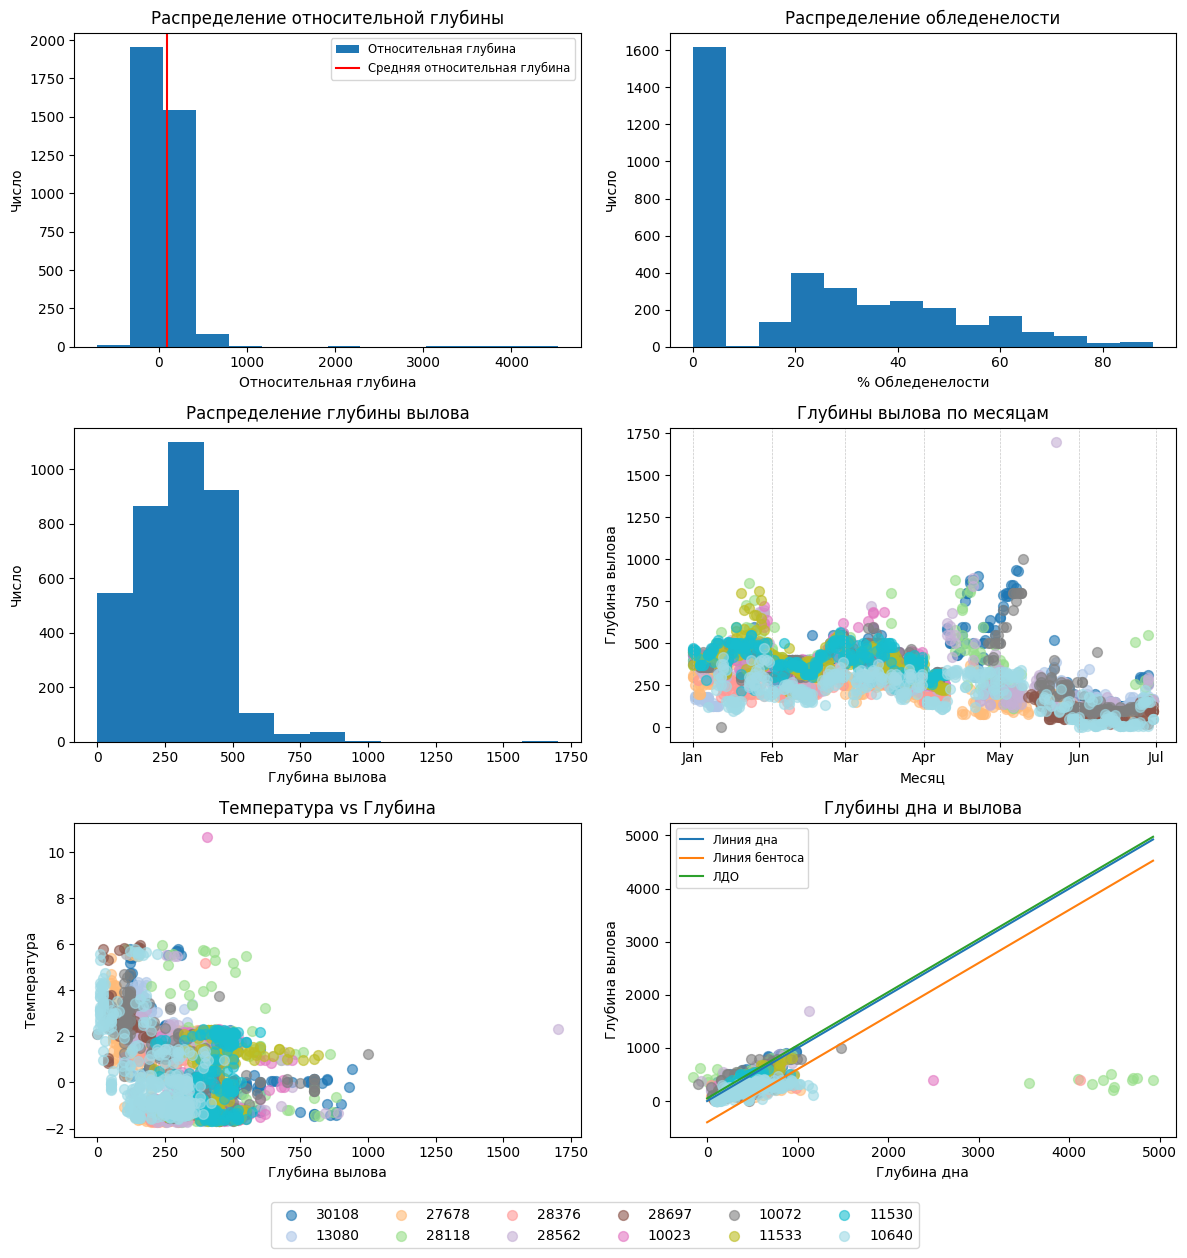

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
def n_bins(x): # Метод Доана
    return int(1+np.log2(len(x)) + np.log2(1 + np.abs(x.skew())/x.sem())) # int(len(x)**0.5) + 1


unique_codes = df['code'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_codes)))
color_dict = dict(zip(unique_codes, colors))

fig, ((ax1, ax2),(ax3, ax4),(ax5, ax6)) = plt.subplots(3, 2, figsize=(12, 12))
ax1.hist(df['relative_depth'], bins=n_bins(df['relative_depth']), label='Относительная глубина')
ax1.axvline(df['relative_depth'].mean(), color='r', label='Средняя относительная глубина')
ax1.set_title('Распределение относительной глубины')
ax1.set_xlabel('Относительная глубина')
ax1.set_ylabel('Число')
ax1.legend(loc='upper right', fontsize='small')

ax2.hist(df['ice'], bins=n_bins(df[~df['ice'].isna()]['ice']))
ax2.set_title('Распределение обледенелости')
ax2.set_xlabel('% Обледенелости')
ax2.set_ylabel('Число')

ax3.hist(df['fishing_depth'], bins=n_bins(df['fishing_depth']), label='Fishing depth')
ax3.set_title('Распределение глубины вылова')
ax3.set_xlabel('Глубина вылова')
ax3.set_ylabel('Число')

handles, labels = [], []
for code, color in zip(unique_codes, colors):
    mask = df['code'] == code
    scatter = ax6.scatter(df.loc[mask, 'depth'], df.loc[mask, 'fishing_depth'], 
               c=[color], s=50, alpha=0.6)
    ax5.scatter(df.loc[mask, 'fishing_depth'], df.loc[mask, 'sst'], 
               c=[color], s=50, alpha=0.6)
    ax4.scatter(df.loc[mask,'formated_date'], df.loc[mask,'fishing_depth'],
                c=[color], s=50, alpha=0.6)
    
    handles.append(scatter)
    labels.append(f'{code}')
    
ax4.set_title('Глубины вылова по месяцам')
ax4.set_xlabel('Месяц')
ax4.set_ylabel('Глубина вылова')
months = [dt_start_date + pd.DateOffset(months=i) for i in range(0, 7)]
ax4.set_xticks(months, [m.strftime('%b') for m in months], minor=False)
ax4.grid(axis='x', linestyle='--', linewidth=0.5, alpha=0.7)

x_span = np.array([0, np.max(df['depth'])])
ax6.plot(x_span, x_span, label='Линия дна')
ax6.plot(x_span, x_span-400, label='Линия бентоса')
ax6.plot(x_span, x_span+50, label='ЛДО') # Линия допустимой ошибки
ax6.legend(loc='upper left', fontsize='small')
ax6.set_title('Глубины дна и вылова')
ax6.set_xlabel('Глубина дна')
ax6.set_ylabel('Глубина вылова')
    
ax5.set_xlabel('Глубина вылова')
ax5.set_ylabel('Температура')
ax5.set_title('Температура vs Глубина')

fig.legend(handles=handles, labels=labels, 
           loc='lower center', bbox_to_anchor=(0.5, -0.05), 
           ncol=(len(unique_codes)+1)//2)


plt.tight_layout()
plt.show();

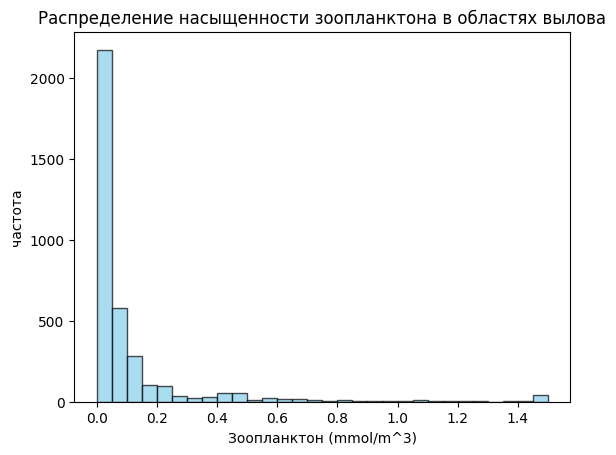

In [64]:

%matplotlib inline
ax = plt.subplot()
ax.hist(df['zoo'].clip(0, 1.5), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('Зоопланктон (mmol/m^3)')
ax.set_ylabel('частота')
ax.set_title('Распределение насыщенности зоопланктона в областях вылова')
plt.show();

In [13]:
def hsl_to_hex(h, s, l):
    """Convert HSL to hex color."""
    import colorsys
    r, g, b = colorsys.hls_to_rgb(h/360, l/100, s/100)
    return '#{:02x}{:02x}{:02x}'.format(int(r*255), int(g*255), int(b*255))

def get_distributed_colors(n, dev=360):
    """Generate n visually distinct colors."""
    colors = []
    for i in range(n):
        hue = (i * dev / n) % dev
        colors.append(hsl_to_hex(hue, 70, 50))
    return colors

In [53]:
@onimage(fc_interesting)
def layer_point(m):
    unique_codes = list(range(6))# df['code'].unique().tolist()
    color_map = ['#713B6F', '#3C4ED2', '#93D4EC', '#B3D516', '#FFE600', '#FE3222']

    ee_colors = ee.Dictionary({str(k): v for k, v in zip(unique_codes, color_map)})

    def styled_f(f):
        month = ee.Date(f.get('date')).get('month').subtract(1)
        color = ee_colors.get(month)
        
        return f.set({
            'style': {
                'color': color,
                'pointSize': 8,
                'pointShape': 'circle'
            }
        })

    fc_styled = layer_point.image.map(styled_f)

    m.addLayer(fc_styled.style(styleProperty='style'), {}, 'Points')

@onimage(gebco)
def layer_depth(m):
    vis_params = {
        'min': -1400,
        'max': 0,
        'palette': ['#000004', '#420a68', '#932667', '#dd513a', '#fca50a', '#fcffa4'] # ['#081d58', '#253494', '#225ea8', '#1d91c0', '#41b6c4', '#7fcdbb', '#c7e9b4']
    }
        
    m.add_layer(layer_depth.image, vis_params, 'Глубина (Gebco)', opacity=0.6)

@onimage(oisst.select('sst'))
def layer_temperature(m):
    visParams = {
        'min': -180.0,
        'max': 500.0,
        'palette': [
            '040274', '040281', '0502a3', '0502b8', '0502ce', '0502e6',
            '0602ff', '235cb1', '307ef3', '269db1', '30c8e2', '32d3ef',
            '3be285', '3ff38f', '86e26f', '3ae237', 'b5e22e', 'd6e21f',
            'fff705', 'ffd611', 'ffb613', 'ff8b13', 'ff6e08', 'ff500d',
            'ff0000', 'de0101', 'c21301', 'a71001', '911003'
        ],
    }

    m.add_layer(layer_temperature.image, visParams, 'Темература', opacity=0.6)

@onimage(oisst.select('ice'))
def layer_ice(m):
    ice_concentration_vis = {
        'min': 0,
        'max': 100,
        'palette': [
            '#ffffff',  # 0% - open water (white)
            '#c6e9ff',  # 10% - very light blue
            '#9ed6ff',  # 20% - light blue
            '#6bc5ff',  # 30% - light-medium blue
            '#3cb0ff',  # 40% - medium blue
            '#1e8fcf',  # 50% - medium-dark blue
            '#0c6b9e',  # 60% - dark blue
            '#054c6e',  # 70% - darker blue
            '#023246',  # 80% - very dark blue
            '#011e2b',  # 90% - almost black-blue
            '#000000'   # 100% - full ice cover (black)
        ]
    }

    m.add_layer(layer_ice.image, ice_concentration_vis, 'Лед', opacity=0.6)

@onimage(plancton)
def layer_plancton(m):
    nppvVis = {
        'min': 0,
        'max': 5,
        'palette': [
            # Синий сегмент (0-24)
            '#000033', '#000066', '#000099', '#0000cc', '#0000ff',
            '#001aff', '#0033ff', '#004dff', '#0066ff', '#0080ff',
            '#0099ff', '#00b3ff', '#00ccff', '#00e6ff', '#00ffff',
            '#1affff', '#33ffff', '#4dffff', '#66ffff', '#80ffff',
            '#99ffff', '#b3ffff', '#ccffff', '#e6ffff', '#ffffff',
            
            # Желтый сегмент (25-49)
            '#ffffe6', '#ffffcc', '#ffffb3', '#ffff99', '#ffff80',
            '#ffff66', '#ffff4d', '#ffff33', '#ffff1a', '#ffff00',
            '#fff200', '#ffe600', '#ffd900', '#ffcc00', '#ffbf00',
            '#ffb300', '#ffa600', '#ff9900', '#ff8c00', '#ff8000',
            '#ff7300', '#ff6600', '#ff5900', '#ff4d00', '#ff4000',
            
            # Красный сегмент (50-99)
            '#ff3300', '#ff2600', '#ff1a00', '#ff0d00', '#ff0000',
            '#f20000', '#e60000', '#d90000', '#cc0000', '#bf0000',
            '#b30000', '#a60000', '#990000', '#8c0000', '#800000',
            '#730000', '#660000', '#590000', '#4d0000', '#400000',
            '#330000', '#260000', '#1a0000', '#0d0000', '#000000',
            
            # Экстремальный красный для max значений (75-99)
            '#ff0000', '#ff0800', '#ff1100', '#ff1900', '#ff2200',
            '#ff2a00', '#ff3300', '#ff3b00', '#ff4400', '#ff4d00',
            '#ff5500', '#ff5e00', '#ff6600', '#ff6e00', '#ff7700',
            '#ff7f00', '#ff8800', '#ff9000', '#ff9900', '#ffa100',
            '#ffaa00', '#ffb200', '#ffbb00', '#ffc300', '#ffcc00'
        ]
    }

    for i in range(1, 51, 12):
        nppv = layer_plancton.image.select(f'zooc_depth{i}')
        m.addLayer(nppv, nppvVis, f'Zooplancton {i}', opacity = 0.7)

## Визуализация

In [83]:
from utils.calculate_region import region_from_df
from utils.image_supplier import supply

m = geemap.Map(zoom = 1)
padding = 2
ebsRegion = region_from_df(df['lat'], df['lon'])

m_filter = ee.Filter.date('2024-06-01', '2024-06-30')
 
# supply(layer_depth, m, ebsRegion=ebsRegion)
supply(layer_ice, m, filter=m_filter, ebsRegion=ebsRegion)
# supply(layer_temperature, m, filter=m_filter, ebsRegion=ebsRegion)
# supply(layer_plancton, m, filter=m_filter, ebsRegion=ebsRegion)
supply(layer_point, m, filter=m_filter)

# m.add("inspector")
m.setCenter(-190.20, 53.12, zoom=4)
m

Map(center=[53.12, -190.2], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

In [55]:
# Сохраняем результат измерений
df.to_csv('result.csv')